# Pathology Ranking of Methods Figure Code

In [1]:
# read in excel file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


path1_df = pd.read_excel('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/patholog_rankings/Cell segmentation benchmark rankings_Wei.xlsx')
path2_df = pd.read_excel('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/patholog_rankings/Cell segmentation benchmark rankings_BK.xlsx')
def process_data(df):
    # Process data 
    df = df.drop(columns=['Unnamed: 0','Unnamed: 1', 'Unnamed: 3', 'Unnamed: 5', 'Unnamed: 7', 'Unnamed: 9', 'Unnamed: 11'])
    df = df.rename(columns={'Unnamed: 2': 'Human Colon', 'Unnamed: 4': 'Human Lung', 'Unnamed: 6': 'Mouse Brain', 'Unnamed: 8': 'Mouse Embryo', 'Unnamed: 10': 'Mouse Intestine', 'Unnamed: 12': 'Mouse Kidney'})
    df = df.drop(index=0)
    return df

path1_df = process_data(path1_df)
path2_df = process_data(path2_df)

import os
path_results = '/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/figures/pathologist_rankings'
os.makedirs(path_results, exist_ok=True)



In [2]:
path1_df

,Human Colon,Human Lung,Mouse Brain,Mouse Embryo,Mouse Intestine,Mouse Kidney
1,A,A,A,A,A,A
2,B,B,B,B,B,B
3,D,D,D,D,D,D
4,C,C,C,C,C,C
5,I,I,I,I,I,E
6,H,J,J,E,J,F
7,F,E,E,F,F,J
8,J,F,H,J,E,I
9,E,H,F,H,H,G
10,G,G,G,G,G,K


In [3]:
path2_df

,Human Colon,Human Lung,Mouse Brain,Mouse Embryo,Mouse Intestine,Mouse Kidney
1,A,A,A,A,A,A
2,B,B,B,B,B,B
3,D,J,D,D,D,J
4,C,D,C,C,C,D
5,I,C,J,J,I,I
6,J,F,I,G,J,C
7,K,E,K,F,F,F
8,E,G,B,I,E,E
9,F,K,E,E,H,G
10,H,I,F,K,K,K


In [13]:
def rankings_to_long(df, expert_name):
    long = (
        df
        .reset_index()
        .rename(columns={"index": "rank"})
        .melt(
            id_vars="rank",
            var_name="tissue",
            value_name="method"
        )
    )
    long[expert_name] = long["rank"]  # make ranks 1-based
    return long[["tissue", "method", expert_name]]

path1_long = rankings_to_long(path1_df, "1_rank")
path2_long = rankings_to_long(path2_df, "2_rank")

df_long = (
    path1_long
    .merge(
        path2_long,
        on=["tissue", "method"],
        how="inner"
    )
)


In [34]:
method_map = {
    'A': 'StarDist Nuclei',
    'B': 'StarDist + Proximity',
    'C': 'StarDist + Voronoi',
    'D': 'Bin2cell',
    'E': 'Cellpose Nuclei',
    'F': 'Cellpose + Proximity',
    'G': 'Cellpose + Voronoi',
    'H': 'STP (untuned)',
    'I': 'STP (tuned)',
    'J': 'Cellpose3 Cytoplasm',
    'K': 'Naive'
}

In [ ]:
from scipy.stats import kendalltau

tau_df = (
    df_long
    .groupby("tissue")
    .apply(
        lambda x: kendalltau(
            x["1_rank"],
            x["2_rank"],
            variant="b"
        )[0]
    )
    .reset_index(name="kendalls_tau_b")
)

/tmp/ipykernel_2885218/104346456.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [23]:
tau_df['kendalls_tau_b'].mean()

0.7172474201275344

In [ ]:
tau_df

,tissue,kendalls_tau_b
0,Human Colon,0.672727
1,Human Lung,0.636364
2,Mouse Brain,0.685303
3,Mouse Embryo,0.636364
4,Mouse Intestine,0.963636
5,Mouse Kidney,0.709091


In [ ]:
# group by tissue and method to get average rank
df_long['avg'] = (df_long['1_rank'] + df_long['2_rank']) / 2
avg_rank_df = df_long.groupby(['method'])['avg'].mean().reset_index()

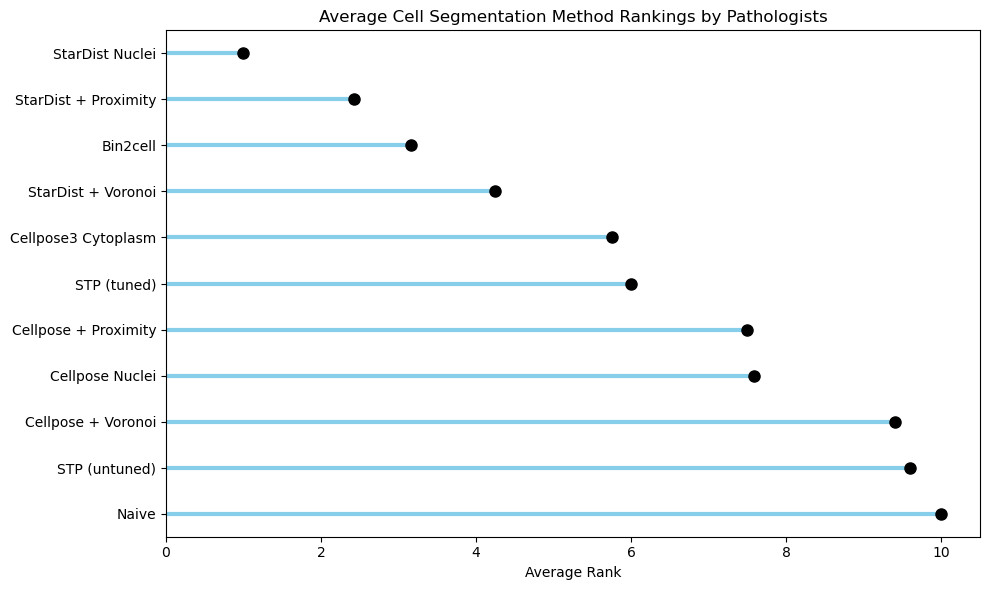

In [44]:
# sort
avg_rank_df = avg_rank_df.sort_values(by='avg')

# rename
y_positions = avg_rank_df['method'].map(method_map)

plt.figure(figsize=(10, 6))

# horizontal lines
plt.hlines(
    y=y_positions,
    xmin=0,
    xmax=avg_rank_df['avg'],
    color='skyblue',
    linewidth=3
)

# dots
plt.plot(
    avg_rank_df['avg'],
    y_positions,
    'o',
    color='black',
    markersize=8
)


plt.xlabel('Average Rank')
plt.title('Average Cell Segmentation Method Rankings by Pathologists')
plt.gca().invert_yaxis()  # highest rank at the top
plt.xlim(left=0)  # ensures lines start exactly at 0
plt.tight_layout()
plt.savefig(path_results + '/average_method_rankings.pdf', dpi=300)
plt.show()
